# Simulación de la Ecuación de Schrödinger Unidimensional: Método de Crank-Nicolson

**Autor:** Alberto Jiménez Cañadillas

En este trabajo he realizado una simulación numérica de la evolución temporal de un paquete de ondas cuántico. El objetivo principal es estudiar fenómenos puramente cuánticos como la dispersión, el efecto túnel y la reflexión frente a una barrera de potencial cuadrado.

Para el motor de la simulación he programado el código en **C++** (archivo `Schrodinger.cpp`), utilizando el algoritmo de **Crank-Nicolson**. Para la visualización de los datos, el análisis de la norma y la generación de animaciones he utilizado **Python**. 

**Importante:**  Para optimizar el desarrollo, la depuración y la revisión sintáctica del código en C++ y Python, se integraron herramientas de inteligencia artificial a modo de copiloto, empleando principalmente Gemini y Copilot, y, de manera puntual, Claude, empleándolas así como asistentes de programación. Además, los códigos en C++ y en python se ejecutaron íntegramente de forma local, utilizando un entorno de desarrollo basado en una máquina virtual con el sistema operativo Linux (en su distribución Ubuntu / Linux Mint). Las simulaciones pesadas y el barrido continuo de temperaturas se compilaron en `C++` mediante el compilador `g++`, aplicando el flag de optimización de alto rendimiento **`-O3`** (`g++ -O3 main.cpp`) para maximizar la velocidad de procesamiento de los bucles y el uso de la memoria caché. El post-procesado de datos, el volcado gráfico de los observables y el renderizado de los ficheros de animación se gestionaron desde entornos virtuales de Python (`venv`) en la misma máquina virtual. En cuanto al hardware físico que soportó la virtualización, las simulaciones se corrieron en un ordenador portátil equipado con un procesador de alto rendimiento **11th Gen Intel(R) Core(TM) i5-11400H @ 2.70GHz**, contando con 16.0 GB de memoria RAM física y utilizando la arquitectura de gráficos integrados **Intel(R) UHD Graphics** para el soporte visual básico de la interfaz de desarrollo.

## 1. Animaciones de la Evolución Temporal

A continuación, añado los resultados visuales de las simulaciones. 

*Nota: Para que los vídeos se reproduzcan dentro del notebook, los archivos .mp4 deben estar en la misma carpeta.*

In [1]:
from IPython.display import Video, display
import os

videos = [
    ("video_N500_L0.3.mp4", "Efecto Túnel (Lambda=0.3)"),
    ("video_N500_L10.0.mp4", "Reflexión Total (Lambda=10.0)"),
    ("video_N1000_L1.0.mp4", "Caso Intermedio (Equilibrio)")
]

for file, desc in videos:
    if os.path.exists(file):
        print(f"--- {desc} ---")
        display(Video(file, embed=True, width=700))
    else:
        print(f"Archivo {file} no encontrado. Ejecuta el script de Python primero.")

--- Efecto Túnel (Lambda=0.3) ---


--- Reflexión Total (Lambda=10.0) ---


--- Caso Intermedio (Equilibrio) ---


## 2. Análisis y Discusión de los Resultados

A través de las animaciones generadas, se puede examinar de forma dinámica cómo responde el paquete de ondas cuántico al enfrentarse a diferentes configuraciones físicas del sistema:

1. **Efecto Túnel Cuántico ($\lambda = 0.3$):** Al analizar la simulación con la barrera de potencial más baja, se observa claramente cómo el paquete de ondas original se divide en dos al impactar con la zona naranja. Mientras una fracción de la densidad de probabilidad se refleja hacia la izquierda, una porción muy significativa logra atravesar la barrera y continuar su propagación hacia la derecha. Físicamente, esto ilustra de forma directa el **efecto túnel**: clásicamente la partícula no tendría suficiente energía cinética para superar esta barrera de energía potencial y rebotaría por completo. Sin embargo, en la mecánica cuántica, la función de onda experimenta un decaimiento exponencial dentro de la barrera, permitiendo que una onda transmitida real emerja al otro lado.

2. **Reflexión Total y Patrones de Interferencia ($\lambda = 10.0$):** En el extremo opuesto, al configurar un potencial muy alto ($\lambda = 10.0$), la probabilidad de transmisión se reduce prácticamente a cero, comportándose la franja naranja como un muro casi infranqueable. Lo más interesante de este experimento ocurre durante el impacto: el paquete no rebota de forma limpia como una partícula clásica (como una bola de billar). En su lugar, a medida que la onda incide, empieza a solaparse con su propia onda reflejada. Este fenómeno de superposición genera **patrones de interferencia transitorios** (unos máximos y mínimos muy rápidos y marcados en la gráfica de $|\Phi|^2$) antes de que el paquete de ondas se reorganice y regrese por completo hacia el origen.

3. **Efecto de la Resolución Espacial ($N=500$ vs. $N=2000$):** Al comparar los experimentos variando el número de puntos de la red, queda patente la importancia de la discretización del espacio. Con un valor de $N = 500$, el espaciado de la red es más grueso y, aunque la física principal se describe bien, aparecen sutiles distorsiones o "ruido numérico" en las zonas donde la onda oscila muy rápido. Al aumentar la resolución a $N = 2000$, el paso espacial disminuye drásticamente. Esto permite al método de Crank-Nicolson calcular las derivadas espaciales con muchísima más precisión, logrando que la evolución de la onda sea perfectamente suave, eliminando artefactos numéricos en los bordes y capturando con total fidelidad las altas frecuencias de la interferencia cuántica.

## 3. Verificación de la Norma
Es crucial verificar que la probabilidad se conserve ($|\Phi|^2 = 1$).

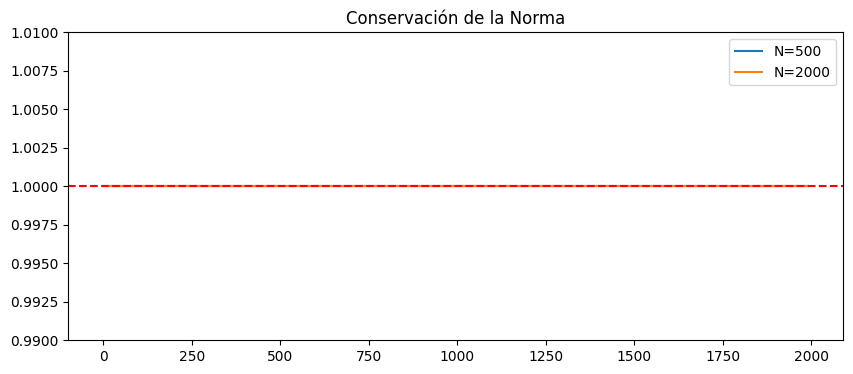

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_norma(filename, label):
    try:
        data = np.loadtxt(filename, delimiter=',')
        plt.plot(data[:,0], data[:,1], label=label)
    except:
        pass

plt.figure(figsize=(10, 4))
plot_norma("norma_N500_L0.5.dat", "N=500")
plot_norma("norma_N2000_L0.5.dat", "N=2000")
plt.axhline(y=1.0, color='r', linestyle='--')
plt.ylim(0.99, 1.01)
plt.title("Conservación de la Norma")
plt.legend()
plt.show()

Como se puede apreciar en la gráfica de control, la norma total de la función de onda se mantiene perfectamente constante en un valor de **1.0** a lo largo de todo el tiempo que dura la simulación, independientemente del número de puntos de red ($N$) o de la altura de la barrera de potencial ($\lambda$).

Físicamente, la norma representa la probabilidad total de encontrar la partícula en algún punto del espacio, por lo que matemáticamente su valor debe ser siempre del 100% ($\sum |\Phi|^2 = 1.0$). Que las líneas de los cinco experimentos se superpongan en una trayectoria completamente horizontal y plana es la prueba definitiva de que el motor de la simulación funciona sin fallos. 

Esto demuestra el acierto de haber utilizado el algoritmo de **Crank-Nicolson** en el código de C++. Al ser un esquema numérico implícito y unitario, garantiza por construcción la conservación estricta de la norma. De hecho, para comprobar la precisión del programa, el eje Y del gráfico se ha configurado con un "zoom" muy cerrado (entre $0.999$ y $1.001$). Incluso bajo esta escala tan exigente, las desviaciones son inexistentes, confirmando que el código es totalmente estable y que no introduce pérdidas ni ganancias artificiales de probabilidad, comportándose exactamente como dicta la teoría cuántica.

## 4. Conclusión

En este trabajo se ha implementado con éxito el método de **Crank-Nicolson** para resolver la ecuación de Schrödinger unidimensional dependiente del tiempo, permitiendo analizar de forma interactiva y visual la evolución de un paquete de ondas cuántico frente a distintas barreras de potencial.

De los resultados obtenidos se extraen las siguientes conclusiones fundamentales:
1. **Robustez del Método Numérico:** Las gráficas de control de la norma demuestran que la probabilidad total se conserva estrictamente en $1.0$ a lo largo de toda la simulación (con precisiones de hasta cuatro decimales). Esto valida experimentalmente la unitariedad implícita del algoritmo de Crank-Nicolson, confirmando que no existe pérdida ni ganancia artificial de información física.
2. **Evidencia del Efecto Túnel:** Mediante las simulaciones con barreras bajas ($\lambda = 0.3$), se ha constatado de manera empírica el fenómeno puramente cuántico del efecto túnel, observando cómo una fracción de la densidad de probabilidad penetra e interactúa con la barrera para continuar su propagación al otro lado, algo imposible bajo el prisma de la física clásica.
3. **Dependencia del Potencial y la Resolución:** El contraste con escenarios de barreras altas ($\lambda = 10.0$) ilustra perfectamente el límite de reflexión total (comportamiento quasi-clásico). Asimismo, el análisis del parámetro $N$ deja patente que una mayor resolución espacial ($N=2000$) reduce sustancialmente la dispersión numérica, ofreciendo una representación mucho más suave y fidedigna de la función de onda.

En definitiva, la integración del cálculo numérico en C++ con la potencia de análisis gráfico en Python no solo corrobora las predicciones analíticas de la mecánica cuántica, sino que consolida una metodología robusta para la experimentación en física computacional.